In [1]:
import numpy as np
np.random.seed(123)
import matplotlib.pyplot as plt
import astropy.units as u
%matplotlib widget
from threeML import XYLike, DataList, Model, PointSource, BayesianAnalysis,\
      Uniform_prior, clone_model, load_analysis_results
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from bhjet.threeML_plugins.BHJetPlugin import BHJetPlugin
from bhjet.threeML_plugins.TargetBlackBody import TargetBlackBody
from tqdm import tqdm

ModuleNotFoundError: No module named 'threeML'

we can set up a 3ML model for the jet (BHJet) and for the targets (e.g. black body), and then combine them and link their distance/redshift

In [ ]:
bhjet3ml = BHJetPlugin()
bhjet3ml._setup(
    Emin_eV=1e-6, Emax_eV=1e8, 
    dlgz=0.1, verbosity_level=0, 
    compton_threshold=1e-10,
    include_counterjet=True, cache_rtol=1e-4)

bbt1 = TargetBlackBody()

bhjet3ml.add_target(bbt1, "bb1")
total = bhjet3ml + bbt1

ps = PointSource("fake_source", ra=0, dec=0, spectral_shape=total)
model = Model(ps)

In [ ]:
model.link(bbt1.lg_distance, bhjet3ml.lg_distance)
model.link(bbt1.redshift, bhjet3ml.redshift)
model

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (27):
--------------------

                                            value min_value max_value unit
fake_source...lg_mass_bh_1                    9.0       1.0      15.0     
fake_source...lg_jet_power_eddington_1       -5.0     -10.0       5.0     
fake_source...lg_z_jet_launching_1            0.3       0.0       5.0     
fake_source...lg_r_initial_1                  0.7       0.0       5.0     
fake_source...lg_z_end_of_acceleration_1      5.3       0.0      10.0     
fake_source...lg_z_dissipation_1              2.0       0.0      10.0     
fake_source...lg_z_max_calculation_1          5.5       0.0      10.0     
fake_source...lg_sigma_final_1                0.0      -5.0       5.0     
fake_source...lg_gamma_final_1                1.0   0.00001       5.0     
fake_source...plasma_beta_jet_base_1          0.0       0.0  100000.0     
...                                           0.0     -10.0      10.0     
fake_source...lg_factor_break_protons_1       0.0     -10.0      10.0     
fake_source...index_injected_electrons_1      2.0     -10.0      10.0     
fake_source...index_injected_protons_1        2.0     -10.0      10.0     
fake_source...theta_obs_1                    17.0       0.0     180.0     
fake_source...lg_distance_1                   4.0       0.0      10.0     
fake_source...redshift_1                  0.00428       0.0    1000.0     
fake_source...lg_temperature_2               -3.5     -10.0      10.0     
fake_source...lg_energy_density_2            -9.0     -20.0      10.0     
fake_source...lg_luminosity_2                44.0       0.0      60.0     

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (2):
----------------------

               fake_source.spectrum.main.composite.lg_distance_2
linked to      fake_source.spectrum.main.composite.lg_distance_1
function                                                    Line
current value                                                4.0
unit                                                            

               fake_source.spectrum.main.composite.redshift_2
linked to      fake_source.spectrum.main.composite.redshift_1
function                                                 Line
current value                                         0.00428
unit                                                         


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

This is just to cross check that cloning the model (and thus yaml export works)

In [ ]:
clone_model(model)

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (27):
--------------------

                                            value min_value max_value unit
fake_source...lg_mass_bh_1                    9.0       1.0      15.0     
fake_source...lg_jet_power_eddington_1       -5.0     -10.0       5.0     
fake_source...lg_z_jet_launching_1            0.3       0.0       5.0     
fake_source...lg_r_initial_1                  0.7       0.0       5.0     
fake_source...lg_z_end_of_acceleration_1      5.3       0.0      10.0     
fake_source...lg_z_dissipation_1              2.0       0.0      10.0     
fake_source...lg_z_max_calculation_1          5.5       0.0      10.0     
fake_source...lg_sigma_final_1                0.0      -5.0       5.0     
fake_source...lg_gamma_final_1                1.0   0.00001       5.0     
fake_source...plasma_beta_jet_base_1          0.0       0.0  100000.0     
...                                           0.0     -10.0      10.0     
fake_source...lg_factor_break_protons_1       0.0     -10.0      10.0     
fake_source...index_injected_electrons_1      2.0     -10.0      10.0     
fake_source...index_injected_protons_1        2.0     -10.0      10.0     
fake_source...theta_obs_1                    17.0       0.0     180.0     
fake_source...lg_distance_1                   4.0       0.0      10.0     
fake_source...redshift_1                  0.00428       0.0    1000.0     
fake_source...lg_temperature_2               -3.5     -10.0      10.0     
fake_source...lg_energy_density_2            -9.0     -20.0      10.0     
fake_source...lg_luminosity_2                44.0       0.0      60.0     

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (2):
----------------------

               fake_source.spectrum.main.composite.lg_distance_2
linked to      fake_source.spectrum.main.composite.lg_distance_1
function                                                    Line
current value                                                4.0
unit                                                            

               fake_source.spectrum.main.composite.redshift_2
linked to      fake_source.spectrum.main.composite.redshift_1
function                                                 Line
current value                                         0.00428
unit                                                         


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

We can change parameters like this

In [ ]:
bbt1.lg_energy_density.value = -1.1234
bhjet3ml.lg_jet_power_eddington.value = -5.1234
bbt1.lg_energy_density, bhjet3ml.lg_jet_power_eddington

(Parameter lg_energy_density_2 = -1.1234 []
 (min_value = -20.0, max_value = 10.0, delta = 0.9, free = True),
 Parameter lg_jet_power_eddington_1 = -5.1234 []
 (min_value = -10.0, max_value = 5.0, delta = 0.5, free = True))

We can evaluate the total model via the point source (called "fake_source") or the components (bhjet3ml, bbt1) or even the bhjet components via bhjet3ml.bhjet

Text(0, 0.5, 'E²dN/dEdtdA [keV/cm²s]')

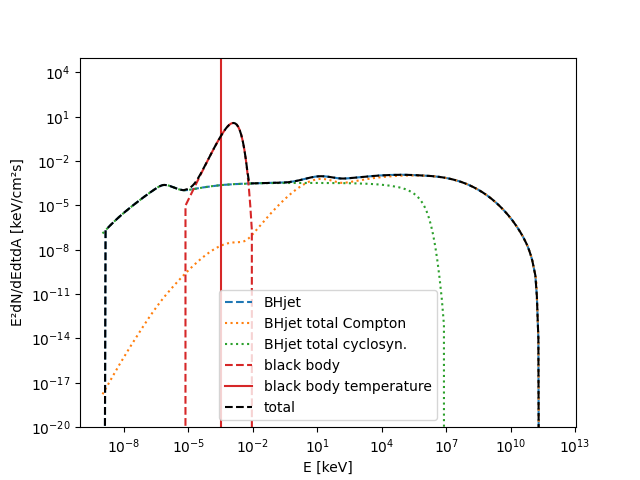

In [ ]:
%matplotlib widget
EskeV = np.logspace(-9, 12, 300)
fig, ax = plt.subplots()


# bhjet
ax.loglog(EskeV, EskeV**2*bhjet3ml(EskeV), label="BHjet", ls="--")
ax.loglog(bhjet3ml.Egrid_keV, bhjet3ml.Egrid_keV* bhjet3ml.bhjet.get_observed_photon_integrated_flux_electron_compton(
    0, 1e30
), ls=":", label="BHjet total Compton")
ax.loglog(bhjet3ml.Egrid_keV, bhjet3ml.Egrid_keV* bhjet3ml.bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    0, 1e30
), ls=":", label="BHjet total cyclosyn.")

# this is just to test that changing parameters works
# for i in np.arange(-4, 2, 2):
#     bbt1.lg_energy_density.value = i
#     ax.loglog(EskeV, EskeV**2*bhjet3ml(EskeV), c="grey", alpha=0.5)
# black body
ax.loglog(EskeV, EskeV**2*bbt1(EskeV), ls="--", label="black body")
ax.axvline(10**bbt1.lg_temperature.value, label="black body temperature", c="tab:red")
# total
ax.loglog(EskeV, EskeV**2*model.fake_source(EskeV), ls="--", label="total", c="k")
ax.legend()
ax.set_ylim(1e-20, 1e5)
ax.set_xlabel("E [keV]")
ax.set_ylabel("E²dN/dEdtdA [keV/cm²s]")

We can test the run time, that the parameter caching works in bhjet

In [13]:
%%time
bhjet3ml.lg_jet_power_eddington.value *= 0.9
bhjet3ml(EskeV)
bhjet3ml.lg_jet_power_eddington.value = -5

CPU times: user 1.17 s, sys: 7.1 ms, total: 1.18 s
Wall time: 1.23 s


In [14]:
%%time
# only first time is recomputed
for i in range(100):
    bhjet3ml(EskeV)
bhjet3ml.lg_jet_power_eddington.value = -5


CPU times: user 1.18 s, sys: 6.19 ms, total: 1.18 s
Wall time: 1.2 s


We can set the bounds, free parameters, and priors

In [ ]:
# bhjet
bhjet3ml.lg_jet_power_eddington.min_value = -6
bhjet3ml.lg_jet_power_eddington.max_value = -4
for par in bhjet3ml.parameters:
    bhjet3ml.parameters[par].free = False
    bhjet3ml.parameters[par].delta = 0.1
    bhjet3ml.parameters[par].prior = Uniform_prior(
        lower_bound=bhjet3ml.parameters[par].min_value,
        upper_bound=bhjet3ml.parameters[par].max_value)

bhjet3ml.lg_jet_power_eddington.free = True

# black body
bbt1.lg_temperature.min_value = -10
bbt1.lg_temperature.max_value = -3 # better change this to something like -1
bbt1.lg_temperature.value = -3
for par in bbt1.parameters:
    bbt1.parameters[par].free = False
    bbt1.parameters[par].delta = 0.1
    bbt1.parameters[par].prior = Uniform_prior(
        lower_bound=bbt1.parameters[par].min_value,
        upper_bound=bbt1.parameters[par].max_value)
bbt1.lg_temperature.free = True

we can generate some fake data to test the fitting

16:42:51 INFO      Using Gaussian statistic (equivalent to chi^2) with the provided errors.            ]8;id=36710;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py\XYLike.py]8;;\:]8;id=512167;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py#90\90]8;;\

Text(0, 0.5, 'E²dN/dE [1/(keV s cm²)]')

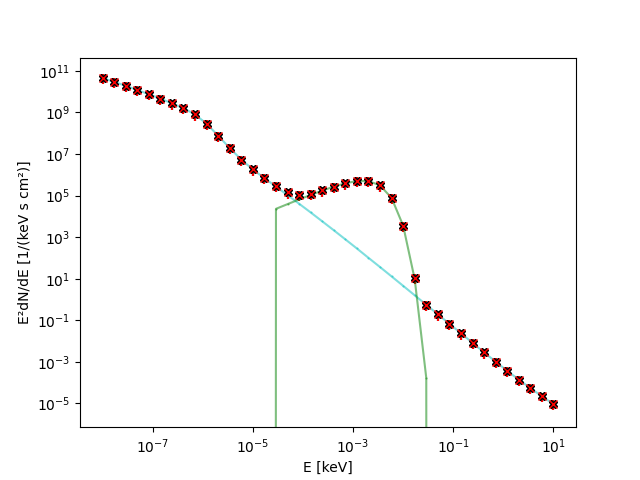

In [16]:
fake_ebins = np.logspace(-8, 1, 40)

bhjet3ml.lg_z_dissipation.value = 2
data_points = model.fake_source(fake_ebins)
uncertainties = 0.5 * data_points 
fake_data = XYLike("fake_data", x=fake_ebins, y=data_points, yerr=uncertainties)

fig, ax = plt.subplots()
fake_data.plot(ax=ax, x_scale='log', y_scale='log')
ax.errorbar(fake_data.x, fake_data.y, yerr=fake_data.yerr, c="k", ls="", marker="X")
ax.errorbar(fake_ebins, data_points , yerr=uncertainties, c="r", ls="", marker="x")
ax.loglog(fake_ebins, bhjet3ml(fake_ebins), c="c", alpha=0.5, marker=".", ms=1, ls="-")
ax.loglog(fake_ebins, bbt1(fake_ebins), c="g", alpha=0.5, marker=".", ms=1, ls="-")
ax.set_xlabel("E [keV]")
ax.set_ylabel("E²dN/dE [1/(keV s cm²)]")

In [17]:
data = DataList(fake_data)


this is to test how smooth the likelihood varies for a test parameter set and sweeping z_dissipation

In [18]:
# way to assign the model to the data
bayes = BayesianAnalysis(model, data)

# Sweep and collect log-likelihood
zdiss_values = np.linspace(1, 4, 200)

spectra = []
Es_eval = np.logspace(-8, 10, 1000)
log_likes = []
num_IC_comps = []
for z in tqdm(zdiss_values, desc="Sweeping lg_z_dissipation"):
    bhjet3ml.lg_z_dissipation.value = z
    log_likes.append(fake_data.get_log_like()) 
    spectra.append(Es_eval**2*model.fake_source(Es_eval))
    num_IC_comps.append(np.sum([bhjet3ml.bhjet.radiation_zones[i].compton_calculation_necessary() for i in range(bhjet3ml.bljet.n_zones)]))
log_likes = np.array(log_likes)
num_IC_comps = np.array(num_IC_comps)

Sweeping lg_z_dissipation: 100%|██████████| 200/200 [03:33<00:00,  1.07s/it]


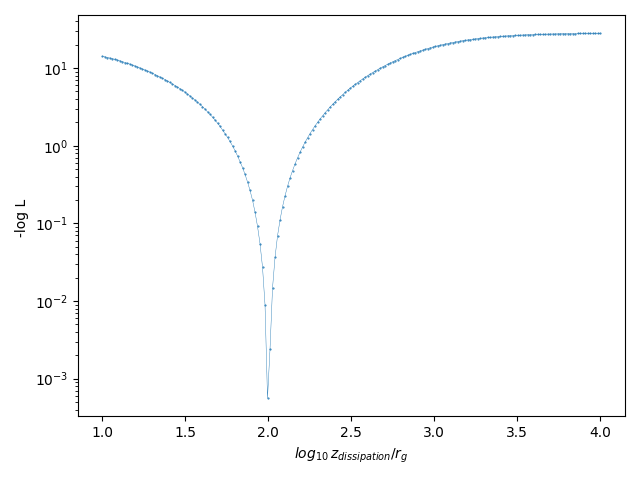

In [26]:
%matplotlib widget
fig, ax = plt.subplots()

ax.semilogy(zdiss_values, -log_likes, ls="-", marker=".", ms=1, lw=0.3)
ax.set_xlabel(r"$log_{10} \, z_{dissipation}/r_g$")
ax.set_ylabel(r"-log L ")
fig.tight_layout()

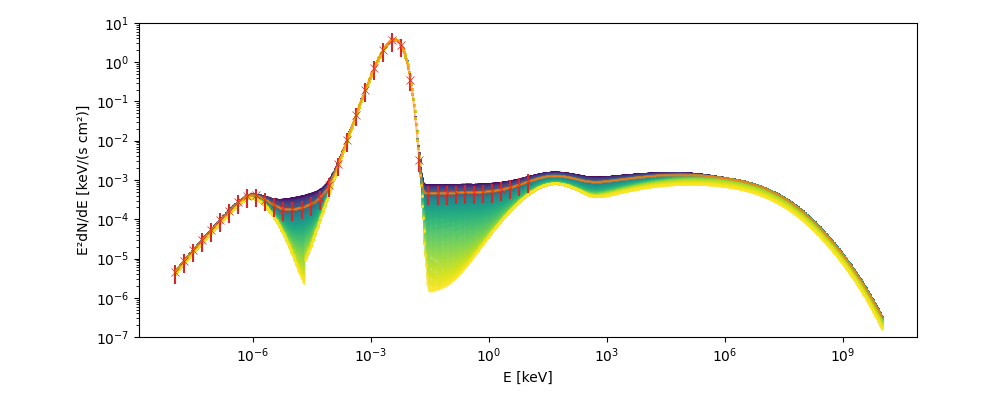

In [25]:
fig, ax = plt.subplots(figsize=(10,4))
Nplots = len(spectra)
cols = plt.get_cmap()(np.linspace(0, 1, Nplots))
for i in range(Nplots):
    
    ax.loglog(Es_eval, spectra[i], c=cols[i], alpha=0.5, marker=".", ms=1, ls="")

ax.errorbar(fake_data.x, fake_data.y * fake_data.x**2, yerr=fake_data.yerr * fake_data.x**2, c="tab:red", ls="", marker="x", markeredgewidth=0.5)
# ax.errorbar(fake_ebins, data_points * fake_ebins**2, yerr=uncertainties * fake_ebins**2, c="r", ls="", marker="X")
bhjet3ml.lg_z_dissipation.value = 2
ax.loglog(Es_eval, Es_eval**2*model.fake_source(Es_eval), c="tab:orange", alpha=0.5, marker=".", ms=1, ls="-")

ax.set_aspect("equal")
ax.set_ylim(1e-7, 1e1)
ax.set_xlabel("E [keV]")
ax.set_ylabel("E²dN/dE [keV/(s cm²)]")
fig.tight_layout()

We can run a fit with ultranest like this

In [21]:
# this took 2hrs on my computer
nlive = 100
bayes = BayesianAnalysis(model, data)
bayes.set_sampler("ultranest")

bayes.sampler.setup(
    log_dir="./ultranest_test",
    min_num_live_points=nlive,
    dlogz=0.5, Lepsilon=0.8,
    resume="resume")
bayes.sample()



16:46:45 INFO      sampler set to ultranest                                                ]8;id=68137;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py\bayesian_analysis.py]8;;\:]8;id=961284;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py#186\186]8;;\

[ultranest] Resuming from 2331 stored points


[ultranest] Explored until L=-0.01  -0.8417..-0.4322]*| it/evals=930/4797 eff=inf% N=100     0 0   100   00 0 
[ultranest] Likelihood function evaluations: 4797
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -9.128 +- 0.1615
[ultranest] Effective samples strategy wants to improve: -6.52..-0.01 (ESS = 241.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.15 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.45, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.16 tail:0.42 total:0.45 required:<0.50
[ultranest] Widening from 100 to 200 live points before L=-7...
[ultranest] Will add 100 live points (x1) at L=-9e+04 ...
[ultranest] Exploring (in particular: L=-93003.41..-0.01) ...
[ultranest] Explored until L=-0.0001  3003.4089..-0.0119] | it/evals=2130/4797 eff=inf% N=200  =100 
[ultranest] Likelihood function evaluations: 4797


16:46:49 INFO      fit restored to maximum of posterior                                         ]8;id=233994;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=908761;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#168\168]8;;\

16:46:51 INFO      fit restored to maximum of posterior                                         ]8;id=655693;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=198365;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#168\168]8;;\

...

,result,unit
parameter,,
fake_source...lg_jet_power_eddington_1,-4.999 -0.032 +0.024,
fake_source...lg_temperature_2,-3.0001 -0.028 -0.0032,


Values of -log(posterior) at the minimum:

,-log(posterior)
fake_data,-0.000257
total,-0.000257


Values of statistical measures:

,statistical measures
AIC,4.324839
BIC,7.378273
DIC,3.489885
PDIC,1.308004
log(Z),-3.970355


We can save data to disk like this

In [22]:
bayes.results.write_to(
    f"./ultranest_test/threeml_results_test_n{nlive}.h5",
    overwrite=True)

We can load it back in like this

In [23]:
ar = load_analysis_results(f"./ultranest_test/threeml_results_test_n{nlive}.h5")

and make e.g. a corner plot to that things make sense

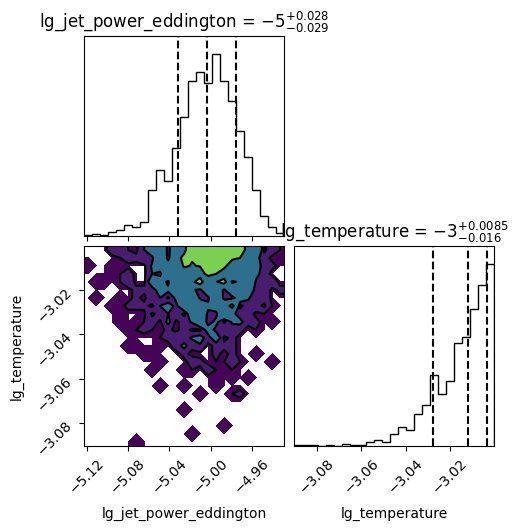

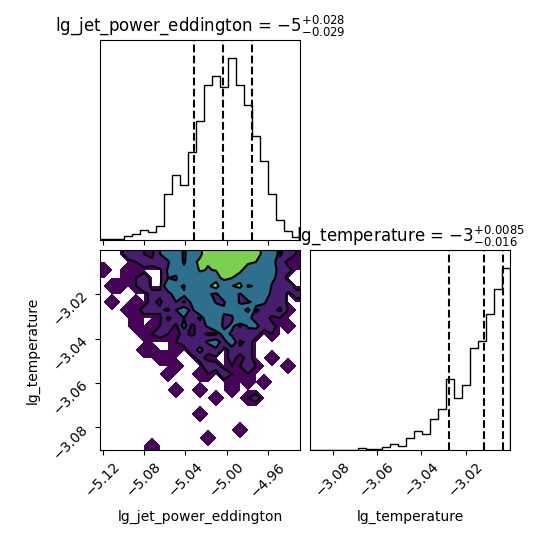

In [59]:
ar.corner_plot()